# KDE Plot: Convective Environment Relationships by Lightning/OT Category

Purpose: Visualize joint distributions (2D KDE contours) between CAPE and two other
convective environment variables (LCL, RH36) across lightning/OT co-occurrence categories
(OT only, OT+LS, LS only), comparing land vs. ocean, to characterize how environmental
conditions differ between categories and surface types.

Input:
- Per-variable point-level KDE datasets (from 09_categorical_environment_kde_extraction.ipynb):
  KDE_dataset_MUCAPE.feather, KDE_dataset_MULCL.feather, KDE_dataset_RH36mean.feather

Processing:
1. Load the three per-variable point-level datasets and convert MULCL units (m to km).
2. Merge all three on shared identifying columns (time, lat, lon, group, contrast) into
   one combined dataset, dropping any rows with missing values.
3. For each lightning/OT category (columns) and each row-pair of variables
   (CAPE-LCL, CAPE-RH36), plot 2D KDE contour lines for Land and Ocean overlaid,
   using a subsample (up to 50,000 points) for large categories.
4. Style the figure to match the companion boxplot figure (fonts, colors, panel labels,
   gridlines, spines).

Output:
- Figure saved to:
  /g/data/if69/tp4064/Project_1/Plots/warm_season/warm_season_KDE_plot.png

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import pyarrow

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df1 = pd.read_feather("/g/data/if69/tp4064/Project_1/categorical_position/Box_plot/1_KDE_dataset_MUCAPE.feather")
df2 = pd.read_feather("/g/data/if69/tp4064/Project_1/categorical_position/Box_plot/1_KDE_dataset_MULCL.feather")
df2['MULCL'] = df2['MULCL']/1000
df3 = pd.read_feather("/g/data/if69/tp4064/Project_1/categorical_position/Box_plot/1_KDE_dataset_RH36mean.feather")

In [3]:
df_final = (
    df1
    .merge(df2, on=['time', 'lat', 'lon','group','contrast'],how='inner')
    .merge(df3, on=['time', 'lat', 'lon','group','contrast'],how='inner')
)
print(len(df1), len(df2), len(df3), len(df_final))

8840345 8840345 8840345 8840345


In [9]:
df_final['lon'].min()

120.05

In [4]:
df_final

,MUCAPE,time,lat,lon,group,contrast,MULCL,RH36mean
0,3528.2,2016-01-06 11:00:00,-16.94,128.19,OT only,Land,1.3782,75.29
1,3692.3,2016-01-06 11:00:00,-16.94,128.30,OT only,Land,1.3499,77.52
2,3323.2,2016-01-06 11:00:00,-17.05,128.19,OT only,Land,1.4172,72.27
3,321.1,2016-01-08 06:00:00,-16.39,127.31,OT only,Land,2.3254,75.54
4,1448.5,2016-01-09 10:00:00,-15.51,125.88,OT only,Land,1.4489,56.47
...,...,...,...,...,...,...,...,...
8840340,1672.3,2024-12-31 22:00:00,-10.01,122.36,LS only,Ocean,0.5615,90.76
8840341,1758.6,2024-12-31 22:00:00,-10.89,121.48,LS only,Ocean,0.5837,83.50
8840342,1589.6,2024-12-31 23:00:00,-10.34,122.25,LS only,Ocean,0.6350,82.76
8840343,1615.9,2024-12-31 23:00:00,-10.34,122.14,LS only,Ocean,0.6300,83.74


In [5]:
dataset = df_final.dropna() 

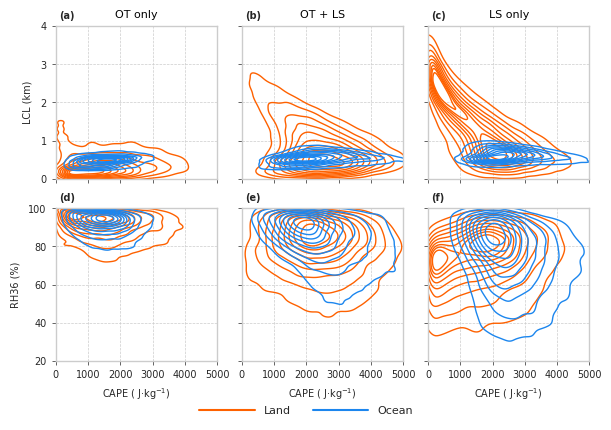

In [11]:
# from scipy.stats import gaussian_kde
# plotting
# ── Match boxplot styling ───────────────────────────────────────
sns.set_theme(style='whitegrid', context='paper')
font_size = 7
font_type = 'DejaVu Sans'
plt.rcParams['font.family'] = font_type

groups = dataset['group'].unique()

color_map = {
    'Land':  '#FE6100',
    'Ocean': '#1C86EE'
}

row_vars = {
    0: ('MUCAPE', 'MULCL'),
    1: ('MUCAPE', 'RH36mean')
}
row_xlabels = {
    0: 'CAPE ( J·kg$^{-1}$)',
    1: 'CAPE ( J·kg$^{-1}$)'
}
row_ylabels = {
    0: 'LCL (km)',
    1: 'RH36 (%)'
}

# ── y-axis limits per row ───────────────────────────────────────
row_ylims = {
    0: (0, 4),      # MULCL 0 to 4 km
    1: (20, 100) # RH36mean — auto
}
row_xlims = {
    0: (0, 5000),   # MUCAPE 0 to 5000
    1: (0, 5000)
}

n_cols = len(groups)

fig, axes = plt.subplots(
    2, n_cols,
    figsize=(6, 4),            # match boxplot figsize
    constrained_layout=True
)

if n_cols == 1:
    axes = axes.reshape(2, 1)

# Per-row axis sharing
for row_idx in range(2):
    for j in range(1, n_cols):
        axes[row_idx, j].sharex(axes[row_idx, 0])
        axes[row_idx, j].sharey(axes[row_idx, 0])

legend_handles = {}

# Panel labels like boxplot
panel_labels = [chr(97 + i) for i in range(n_cols * 2)]  # a, b, c, ...
panel_idx = 0

for j, g in enumerate(groups):
    df_g = dataset[dataset['group'] == g]

    for row_idx in range(2):
        ax = axes[row_idx, j]
        x_var, y_var = row_vars[row_idx]

        # Title on top row only
        if row_idx == 0:
            ax.set_title(str(g), fontsize=font_size+1, pad=6, color='black')

        for contrast in df_g['contrast'].unique():
            df_g_c = df_g[df_g['contrast'] == contrast].dropna(subset=[x_var, y_var])
            color = color_map[contrast]
            # print(f"{len(df_g_c)}")
            if len(df_g_c) < 50000 :
                
                sample = df_g_c

            else :
                
                sample = df_g_c.sample(n=min(50000, len(df_g_c)), random_state=42)
            
            # remove NaNs
            sample = sample[[x_var, y_var]].dropna()
            
            if len(sample) < 2:
                continue
            
            sns.kdeplot(
                data=sample,
                x=x_var,
                y=y_var,
                ax=ax,
                levels=10,
                color=color,
                linewidths=1.0,
                fill=False,      # contour only
                thresh=0.08
            )

            # sample = df_g_c.sample(n=min(5000, len(df_g_c)), random_state=42)
            # x = sample[x_var].values
            # y = sample[y_var].values

            # if len(x) < 2:
            #     continue

            # kde = gaussian_kde(np.vstack([x, y]))
            # xi = np.linspace(x.min(), x.max(), 200)
            # yi = np.linspace(y.min(), y.max(), 200)
            # Xi, Yi = np.meshgrid(xi, yi)
            # Zi = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)

            # ax.contour(
            #     Xi, Yi, Zi,
            #     levels=6,
            #     colors=color,
            #     linewidths=0.8,      # thinner like boxplot lines
            #     # alpha=0.9
            # )

            if contrast not in legend_handles:
                legend_handles[contrast] = plt.Line2D(
                    [], [], color=color, linewidth=1.5, label=contrast
                )

        # ── Apply axis limits ───────────────────────────────────
        ax.set_xlim(row_xlims[row_idx])
        if row_ylims[row_idx][0] is not None:
            ax.set_ylim(row_ylims[row_idx])

        # ── Grid & spines like boxplot ──────────────────────────
        ax.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', zorder=0)
        ax.set_axisbelow(True)
        
        ax.tick_params(axis='both', labelsize=font_size, direction='out', length=3, width=0.5, bottom=True, left=True)
        ax.set_xlabel('')
        ax.set_ylabel('')
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('#cccccc')
            spine.set_linewidth(1)

        # Panel label like boxplot (a), (b), ...
        label_idx = row_idx * n_cols + j
        ax.text(0.02, 1.1, f"({panel_labels[label_idx]})",
                transform=ax.transAxes, fontsize=font_size,
                fontweight='bold', va='top')
        panel_idx += 1



# ── Axis labels — x only on bottom row, y only on left col ──────
for j in range(n_cols):
    axes[0, j].set_xlabel('')
    axes[1, j].set_xlabel(row_xlabels[1], fontsize=font_size, labelpad=4)  # bottom row only

axes[0, 0].set_ylabel(row_ylabels[0], fontsize=font_size, labelpad=6)  # left col only
axes[1, 0].set_ylabel(row_ylabels[1], fontsize=font_size, labelpad=6)  # left col only
# ax.tick_params(axis='both', which='both', direction='out', length=3, width=0.5, colors='#2d2d2d')


for j in range(n_cols):
    axes[0, j].tick_params(labelbottom=False)   # hide x tick labels on top row
    for row_idx in range(2):
        if j > 0:
            axes[row_idx, j].tick_params(labelleft=False)  # hide y tick labels on non-left cols
# ── Legend ───────────────────────────────────────────────────────
legend = fig.legend(
    handles=list(legend_handles.values()),
    loc='lower center',
    ncol=len(legend_handles),
    frameon=False,               # match boxplot frameon=False
    fontsize=font_size+1,
    bbox_to_anchor=(0.5, -0.05),
    handlelength=5
)

# plt.subplots_adjust(hspace=0.4, wspace=0.35)  # match boxplot spacing
plt.savefig("/g/data/if69/tp4064/Project_1/Plots/warm_season/warm_season_KDE_plot.png", dpi = 400, bbox_inches='tight', bbox_extra_artists=(legend,))
plt.show()
